# Parte 1: Regressão — Student Performance

## 1.1 Análise Exploratória (EDA)

Primeiramente, foi analisada a estrutura do dataset para identificar o tipo de cada uma das 30 features, verificando a presença de valores nulos e mapeando a distribuição estatística e correlações da nota alvo antes de pensar em aplicar qualquer modelo.

>>> Informações do dataset de regressão
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   school      395 non-null    object 
 1   sex         395 non-null    object 
 2   age         395 non-null    int64  
 3   address     395 non-null    object 
 4   famsize     395 non-null    object 
 5   Pstatus     395 non-null    object 
 6   Medu        395 non-null    int64  
 7   Fedu        395 non-null    int64  
 8   Mjob        395 non-null    object 
 9   Fjob        395 non-null    object 
 10  reason      395 non-null    object 
 11  guardian    395 non-null    object 
 12  traveltime  395 non-null    int64  
 13  studytime   395 non-null    int64  
 14  failures    395 non-null    int64  
 15  schoolsup   395 non-null    object 
 16  famsup      395 non-null    object 
 17  paid        395 non-null    object 
 18  activities  395 non-null    ob

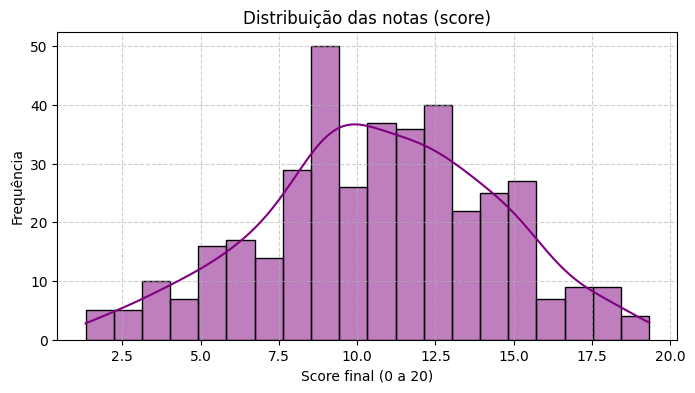

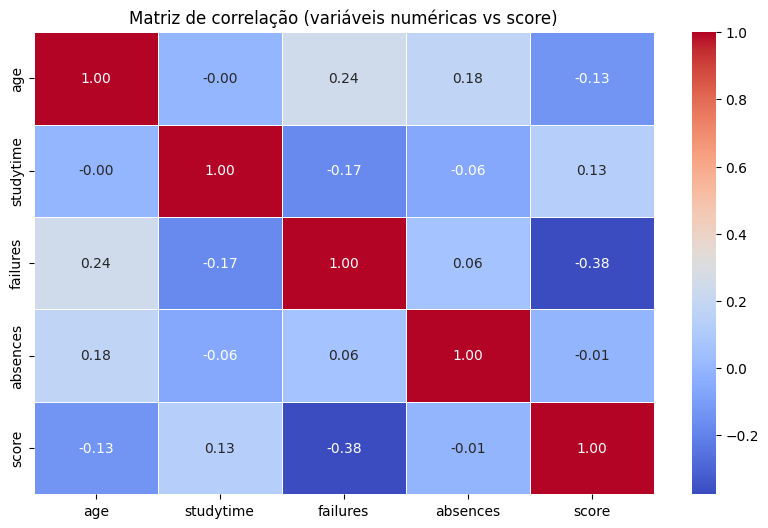

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error, mean_squared_error

train_reg = pd.read_csv('regressao/train.csv')
test_reg = pd.read_csv('regressao/test.csv')


# Informações gerais e valores ausentes
print(">>> Informações do dataset de regressão")
print(train_reg.info())
print("\nTotal de valores nulos:", train_reg.isnull().sum().sum())

# Estatísticas descritivas do alvo e principais features
print("\n>>> Estatísticas descritivas do alvo (score)")
print(train_reg['score'].describe())

# Gráfico de distribuição do score
plt.figure(figsize=(8, 4))
sns.histplot(train_reg['score'], kde=True, color='purple', bins=20)
plt.title('Distribuição das notas (score)')
plt.xlabel('Score final (0 a 20)')
plt.ylabel('Frequência')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Gráfico de correlação entre algumas variáveis numéricas e o score
plt.figure(figsize=(10, 6))
numeric_subset = train_reg[['age', 'studytime', 'failures', 'absences', 'score']]
sns.heatmap(numeric_subset.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de correlação (variáveis numéricas vs score)')
plt.show()

## 1.2 Pré-processamento, treinamento e modelagem de regressão

Nesse bloco são separadas as variáveis explicativas da variável alvo (y). Também foi feito um tratamento das colunas numéricas e categóricas com ColumnTransformer. Após, foi aplicado o StandardScaler para colunas numéricas e codificação OneHotEncoder para categóricas. E então, foram testados modelos lineares e ensembles, como Random Forest e Gradient Boosting:

In [4]:
X_reg = train_reg.drop('score', axis=1)
y_reg = train_reg['score']

# Separa os tipos de colunas
numeric_cols = X_reg.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_reg.select_dtypes(include=['object']).columns.tolist()

# Pre-processamento
preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

# Divisão de treino e validação
X_train, X_val, y_train, y_val = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Modelos para comparação
models_reg = {
    "Regressão Linear": LinearRegression(),
    "Ridge (Alpha=10)": Ridge(alpha=10.0),
    "Lasso": Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results_reg = {}
for name, model in models_reg.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor_reg), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    results_reg[name] = rmse
    print(f"{name} - Validação RMSE: {rmse:.4f}")

Regressão Linear - Validação RMSE: 3.3750
Ridge (Alpha=10) - Validação RMSE: 3.3437
Lasso - Validação RMSE: 3.4467
Random Forest - Validação RMSE: 3.3293
Gradient Boosting - Validação RMSE: 3.3389


# Parte 2: Classificação — Breast Cancer

## 2.1 Análise exploratória (EDA)



Foram examinadas as dimensões da base de dados e a proporção entre as classes da variável alvo, o diagnosis, para determinar o grau de desbalanceamento das amostras e definir o baseline da acurácia de referência.

>>> Informações do dataset de classificação
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-nul

/tmp/ipykernel_885/1607484794.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=train_class, palette='Set2')


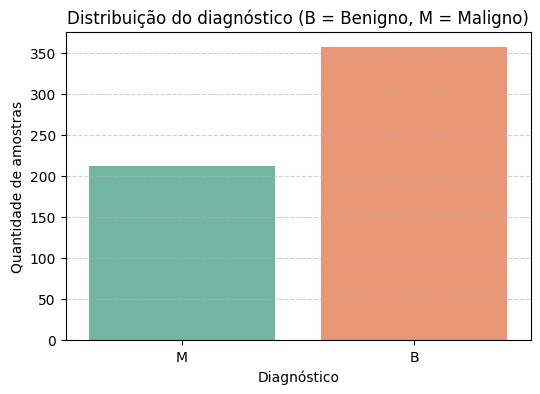

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

train_class = pd.read_csv('classiicacao/train2.csv')
test_class = pd.read_csv('classiicacao/test2.csv')

# Informações gerais
print(">>> Informações do dataset de classificação")
print(train_class.info())
print("\nTotal de valores nulos:", train_class.isnull().sum().sum())

# Distribuição das classes
print("\n>>> Contagem das classes (diagnosis)")
print(train_class['diagnosis'].value_counts())

print("\n>>> Proporção das classes (Baseline)")
print(train_class['diagnosis'].value_counts(normalize=True) * 100)

# Gráfico de distribuição de diagnósticos
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=train_class, palette='Set2')
plt.title('Distribuição do diagnóstico (B = Benigno, M = Maligno)')
plt.xlabel('Diagnóstico')
plt.ylabel('Quantidade de amostras')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

Foi identificada a ausência de dados nulos e o desbalanceamento leve das classes (62.74% benignos e 37.26% malignos), o que estabelece o baseline de acurácia em 62.74%.  

## 2.2 Pré-processamento, treinamento e matriz de confusão

Acurácia na validação: 0.9737


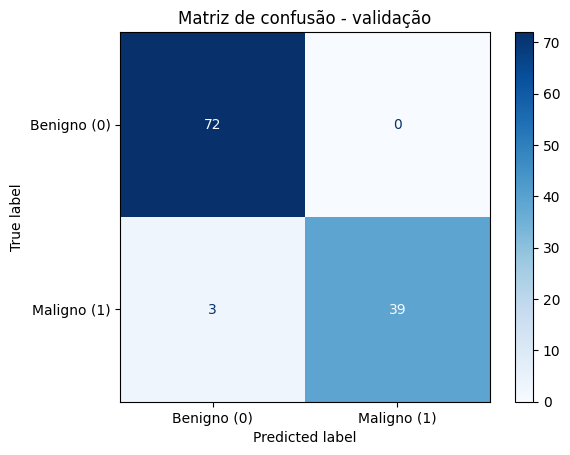

In [6]:
# Separa features (X) e alvo (y) e convertendo B/M para 0/1
X_class = train_class.drop('diagnosis', axis=1)
y_class = train_class['diagnosis'].map({'B': 0, 'M': 1})

X_c_train, X_c_val, y_c_train, y_c_val = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# treina o pipeline de classificação
clf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42))
])

clf_pipeline.fit(X_c_train, y_c_train)

# Acuracia
preds_val = clf_pipeline.predict(X_c_val)
acc = accuracy_score(y_c_val, preds_val)
print(f"Acurácia na validação: {acc:.4f}")

# Matriz de confusão
cm = confusion_matrix(y_c_val, preds_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno (0)', 'Maligno (1)'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de confusão - validação")
plt.show()

# Parte 3: Preparando modelos para o Kaggle

## 3.1 Gerando o `submission_regressao.csv`

Após escolher o modelo com melhor desempenho (Random Forest), foi realizado o treino com todo o conjunto de treino e gerado o arquivo CSV de submissão.

In [14]:
# Treina o modelo final com Random Forest, que teve o melhor resultado
best_reg_model = Pipeline(steps=[
    ('preprocessor', preprocessor_reg),
    ('model', RandomForestRegressor(random_state=42))
])
best_reg_model.fit(X_reg, y_reg)

test_preds = best_reg_model.predict(test_reg)

submission_reg = pd.DataFrame({
    'id': range(len(test_reg)),
    'score': test_preds
})

submission_reg.to_csv('submission_regressao.csv', index=False)
print("Arquivo de submissão de regressão (com Random Forest) gerado com sucesso!")
print(submission_reg.head())

Arquivo de submissão de regressão (com Random Forest) gerado com sucesso!
   id    score
0   0  13.3669
1   1  10.7227
2   2   5.7108
3   3  11.0928
4   4  12.3493


## 3.2 Gerando o `submission_regressao_v2.csv`

Como a pontuação de acerto do Kaggle foi baixa para esse modelo, decidi fazer outro modelo, usando Ridge, para ver se resulta em um acerto maior ou não. Ao submeter no Kaggle, ele teve um desempenho levemente melhor do que usando o Random Forest (pontuação de 7.11301 com Ridge, comparado com o valor maior de 7.18862 obtido usando Random Forest)

In [11]:
# Treina o modelo final com Ridge
best_reg_model = Pipeline(steps=[
    ('preprocessor', preprocessor_reg),
    ('model', Ridge(alpha=10.0))
])
best_reg_model.fit(X_reg, y_reg)

test_preds = best_reg_model.predict(test_reg)

# Criando o df de submissão
submission_reg = pd.DataFrame({
    'id': range(len(test_reg)),
    'score': test_preds
})

submission_reg.to_csv('submission_regressao.csv', index=False)
print("Arquivo de submissão de regressão gerado com sucesso!")
print(submission_reg.head())

Arquivo de submissão de regressão gerado com sucesso!
   id      score
0   0  10.834323
1   1  11.534325
2   2  10.537814
3   3  11.085873
4   4  10.662762


## 3.3 Gerando o `submission_classificacao.csv`

In [12]:
# Treina o modelo final de classificação com dados de treino
clf_pipeline.fit(X_class, y_class)
test_preds_class = clf_pipeline.predict(test_class)

# Criando df com diagnosis de 0 ou 1
submission_class = pd.DataFrame({
    'id': range(len(test_class)),
    'diagnosis': test_preds_class
})
submission_class.to_csv('submission_classificacao.csv', index=False)
print(submission_class.head())

   id  diagnosis
0   0          0
1   1          0
2   2          0
3   3          1
4   4          0
